# Titanic Survival Prediction

A machine learning classification project to predict whether a passenger survived the Titanic disaster based on passenger and travel-related features.

## 1. Problem Statement

The objective of this project is to predict passenger survival using the available passenger and travel-related information.

This project follows an end-to-end machine learning workflow covering data exploration, feature preparation, preprocessing, model comparison, evaluation, cross-validation, and hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer  
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score



## 2. Dataset Overview

The Titanic dataset contains passenger-level information such as passenger class, sex, age, family relationships, fare, cabin information, and port of embarkation.

The target variable is `Survived`, where:

- `0` represents a passenger who did not survive
- `1` represents a passenger who survived

In [2]:
df = pd.read_csv("../data/raw/train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3. Exploratory Data Analysis

Exploratory data analysis was performed to understand the target distribution, relationships between features and survival, missing values, and potentially useful derived features.

### 3.1 Target Distribution

First, the distribution of the target variable is examined to understand the proportion of survivors and non-survivors.

In [9]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### 3.2 Survival by Sex

Survival rates are compared across passenger sex to identify whether survival outcomes differed substantially between these groups.

In [10]:
df.groupby("Sex")["Survived"].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [11]:
survival_rate = df.groupby("Sex")["Survived"].value_counts(normalize=True) * 100
survival_rate

Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64

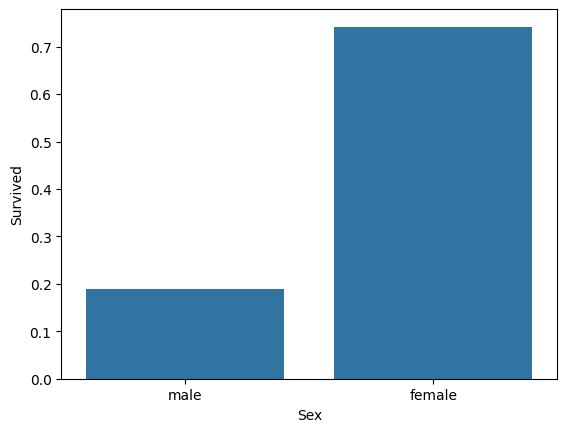

In [12]:
sns.barplot(x="Sex", y="Survived", data=df, errorbar=None)
plt.show()

Female passengers had a substantially higher survival rate than male passengers in this dataset. This indicates that `Sex` is likely to be an important predictive feature.

### 3.3 Survival by Passenger Class

Survival rates are examined across passenger classes to understand whether passenger class is associated with survival outcomes.

In [13]:
df.groupby("Pclass")["Survived"].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [14]:
survival_rate_class = df.groupby("Pclass")["Survived"].value_counts(normalize=True)*100
survival_rate_class

Pclass  Survived
1       1           62.962963
        0           37.037037
2       0           52.717391
        1           47.282609
3       0           75.763747
        1           24.236253
Name: proportion, dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

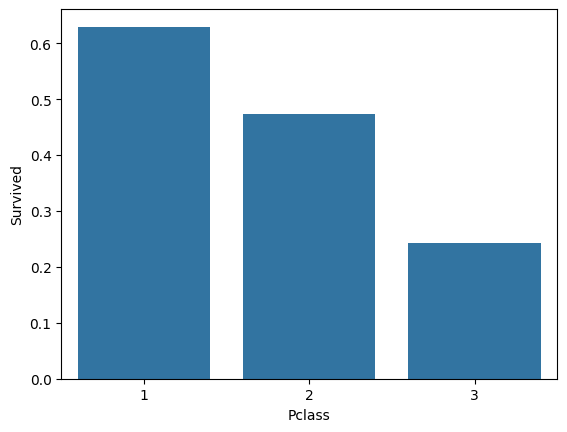

In [15]:
sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None)

Survival rates were higher among first-class passengers and lower among third-class passengers in this dataset, suggesting that `Pclass` may contain useful predictive information.

### 3.4 Sex and Passenger Class

The relationship between sex, passenger class, and survival is examined together to determine whether the survival pattern differs across these groups.

In [16]:
survival_rate_both = df.groupby(["Sex", "Pclass"])["Survived"].value_counts(normalize=True)*100
survival_rate_both

Sex     Pclass  Survived
female  1       1           96.808511
                0            3.191489
        2       1           92.105263
                0            7.894737
        3       0           50.000000
                1           50.000000
male    1       0           63.114754
                1           36.885246
        2       0           84.259259
                1           15.740741
        3       0           86.455331
                1           13.544669
Name: proportion, dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

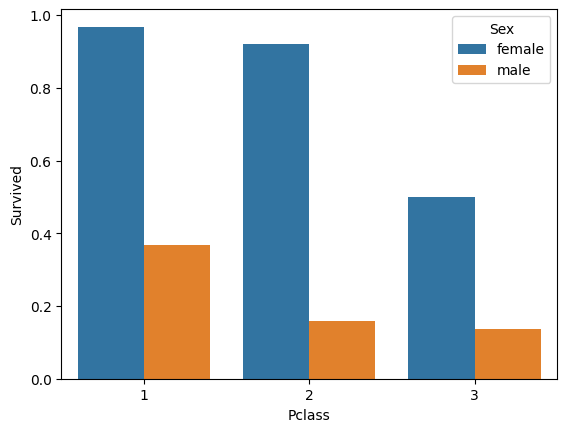

In [17]:
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df, errorbar=None)

The combination of sex and passenger class shows substantial differences in survival rates. This suggests that the effect of individual features may depend on other passenger characteristics.

### 3.5 Port of Embarkation

The distribution of passengers across embarkation ports and their corresponding survival rates are examined.

In [18]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [19]:
df.groupby("Embarked")["Survived"].value_counts()

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           217
Name: count, dtype: int64

In [20]:
survival_rate_embarked = df.groupby("Embarked")["Survived"].value_counts(normalize=True)*100
survival_rate_embarked

Embarked  Survived
C         1           55.357143
          0           44.642857
Q         0           61.038961
          1           38.961039
S         0           66.304348
          1           33.695652
Name: proportion, dtype: float64

<Axes: xlabel='Embarked', ylabel='Survived'>

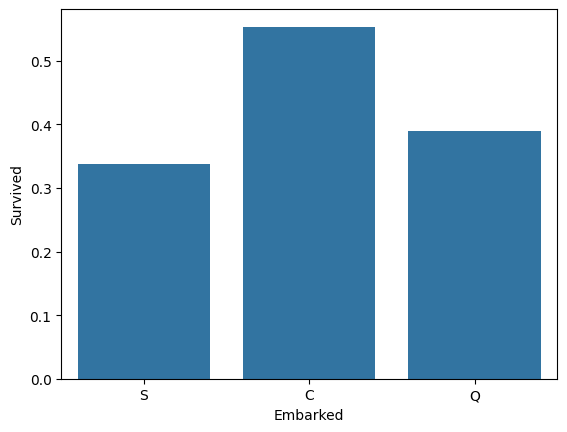

In [21]:
sns.barplot(x="Embarked", y="Survived", data=df, errorbar=None)

Survival rates differ across embarkation ports. However, these differences may partly reflect differences in passenger composition, such as sex and passenger class.

### 3.6 Age

Age is examined through its distribution, relationship with survival, and missingness.

In [22]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

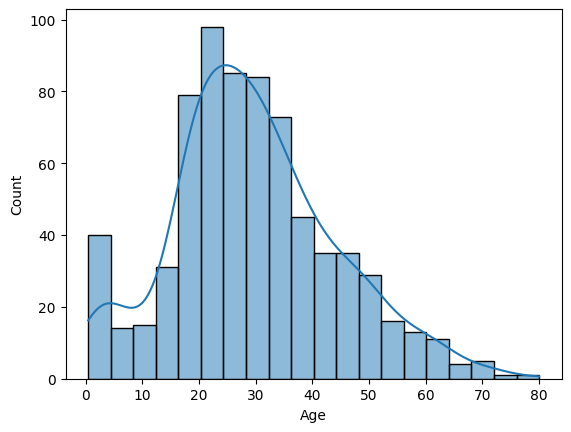

In [23]:
sns.histplot(df["Age"], kde=True)

<Axes: xlabel='Survived', ylabel='Age'>

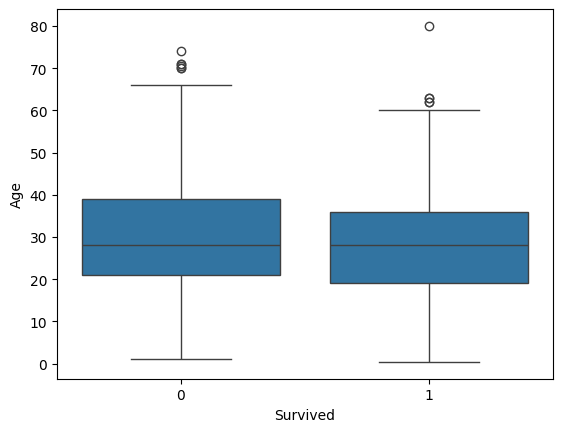

In [24]:
sns.boxplot(x="Survived", y="Age", data=df)

In [25]:
df.groupby("Survived")["Age"].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [26]:
df.groupby(df["Age"].isna())["Survived"].mean()

Age
False    0.406162
True     0.293785
Name: Survived, dtype: float64

Age contains 177 missing values. The observed age distributions for survivors and non-survivors overlap considerably, while the missingness itself is associated with different survival rates.

For this project, missing age values will be handled using median imputation within the preprocessing pipeline.

### 3.7 Fare

Fare is examined to understand its distribution and its relationship with survival.

In [27]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Count'>

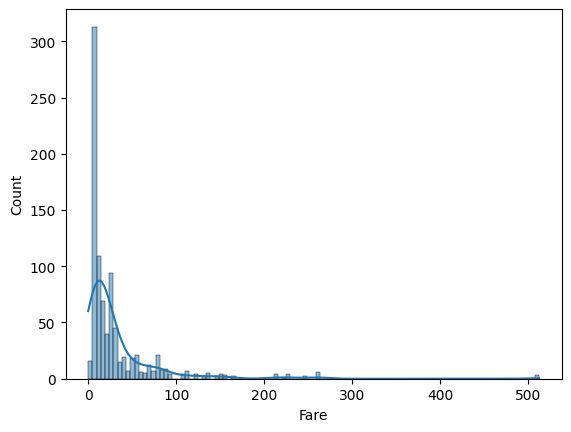

In [28]:
sns.histplot(df["Fare"], kde=True)

<Axes: xlabel='Survived', ylabel='Fare'>

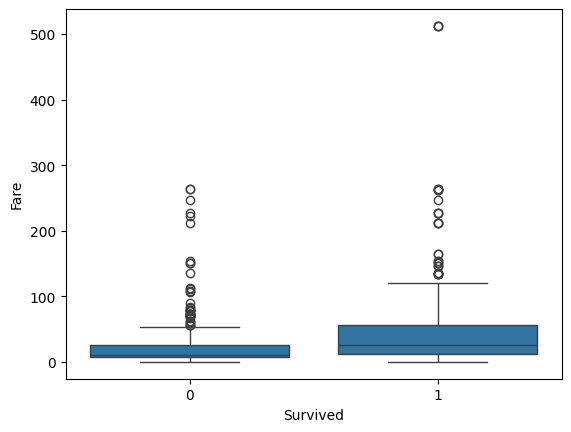

In [29]:
sns.boxplot(x="Survived", y="Fare", data=df)

In [30]:
df.groupby("Survived")["Fare"].median()

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64

Fare is strongly right-skewed, with a small number of relatively high values. Survivors have a higher median fare than non-survivors in this dataset.

The high values are retained rather than removed automatically, since they may represent legitimate passenger fares.

### 3.8 Family-related Features

`SibSp` and `Parch` are examined to understand whether family relationships are associated with survival.

A derived `FamilySize` feature is then created as:

`FamilySize = SibSp + Parch + 1`

In [31]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [32]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [33]:
survival_rate_sibsp = df.groupby("SibSp")["Survived"].value_counts(normalize=True)*100
survival_rate_sibsp

SibSp  Survived
0      0            65.460526
       1            34.539474
1      1            53.588517
       0            46.411483
2      0            53.571429
       1            46.428571
3      0            75.000000
       1            25.000000
4      0            83.333333
       1            16.666667
5      0           100.000000
8      0           100.000000
Name: proportion, dtype: float64

In [34]:
survival_rate_parch = df.groupby("Parch")["Survived"].value_counts(normalize=True)*100
survival_rate_parch

Parch  Survived
0      0            65.634218
       1            34.365782
1      1            55.084746
       0            44.915254
2      0            50.000000
       1            50.000000
3      1            60.000000
       0            40.000000
4      0           100.000000
5      0            80.000000
       1            20.000000
6      0           100.000000
Name: proportion, dtype: float64

In [35]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [36]:
df["FamilySize"].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [37]:
survival_rate_familysize = df.groupby(df["FamilySize"])["Survived"].value_counts(normalize=True)*100
survival_rate_familysize

FamilySize  Survived
1           0            69.646182
            1            30.353818
2           1            55.279503
            0            44.720497
3           1            57.843137
            0            42.156863
4           1            72.413793
            0            27.586207
5           0            80.000000
            1            20.000000
6           0            86.363636
            1            13.636364
7           0            66.666667
            1            33.333333
8           0           100.000000
11          0           100.000000
Name: proportion, dtype: float64

In [38]:
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### 3.9 Feature Decisions

Several columns were reviewed for their usefulness, completeness, and suitability for the initial modeling approach.

In [39]:
df["Cabin"].isna().sum()

np.int64(687)

In [40]:
df["Cabin"].notna().sum()

np.int64(204)

In [41]:
df["Cabin"].dropna().head(20)

1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33
54            B30
55            C52
61            B28
62            C83
66            F33
75          F G73
88    C23 C25 C27
92            E31
96             A5
97        D10 D12
Name: Cabin, dtype: object

In [42]:
df["Cabin"].nunique()

147

In [43]:
df.groupby(df["Cabin"].isna())["Survived"].mean()

Cabin
False    0.666667
True     0.299854
Name: Survived, dtype: float64

`Cabin` has 687 missing values out of 891 observations and contains many distinct cabin values. Although cabin availability is associated with survival in this dataset, the raw feature is highly incomplete and would require additional feature engineering.

For this warm-up project, the raw `Cabin` column is therefore excluded.

The raw `Name` and `Ticket` columns were also reviewed.

`Name` contains high-cardinality text, while `Ticket` contains many unique and irregular identifiers. Both could potentially be transformed into structured features, but that would add additional feature engineering that is not necessary for this warm-up project.

Therefore, the raw `Name` and `Ticket` columns are excluded.

In [44]:
df["Name"].unique()

array(['Braund, Mr. Owen Harris',
       'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
       'Heikkinen, Miss. Laina',
       'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
       'Allen, Mr. William Henry', 'Moran, Mr. James',
       'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard',
       'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
       'Nasser, Mrs. Nicholas (Adele Achem)',
       'Sandstrom, Miss. Marguerite Rut', 'Bonnell, Miss. Elizabeth',
       'Saundercock, Mr. William Henry', 'Andersson, Mr. Anders Johan',
       'Vestrom, Miss. Hulda Amanda Adolfina',
       'Hewlett, Mrs. (Mary D Kingcome) ', 'Rice, Master. Eugene',
       'Williams, Mr. Charles Eugene',
       'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)',
       'Masselmani, Mrs. Fatima', 'Fynney, Mr. Joseph J',
       'Beesley, Mr. Lawrence', 'McGowan, Miss. Anna "Annie"',
       'Sloper, Mr. William Thompson', 'Palsson, Miss. Torborg Danira',
       'Asplund, Mrs. Carl Oscar 

In [45]:
df["Ticket"].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

## 4. Feature Selection and Engineering

Based on the exploratory analysis, the following features are retained for modeling:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`
- `FamilySize`

`PassengerId`, `Name`, `Ticket`, and `Cabin` are excluded for the reasons discussed above.

`Survived` is used as the target variable.

In [46]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "FamilySize"]]
y = df["Survived"]

In [47]:
print(X.shape)
print(y.shape)

(891, 8)
(891,)


## 5. Train-Test Split

The data is divided into training and test sets before fitting any preprocessing steps or models.

An 80/20 split is used with stratification on the target variable so that the class distribution is approximately preserved in both sets.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 6. Data Preprocessing

The preprocessing strategy is defined separately for numerical and categorical features.

### Numerical Features

- Missing values → median imputation
- Scaling → `StandardScaler`

### Categorical Features

- Missing values → most-frequent imputation
- Encoding → one-hot encoding

All preprocessing is included inside a `ColumnTransformer` and later combined with the model in a pipeline to prevent data leakage.

In [49]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [50]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, ["Age", "Fare", "SibSp", "Parch", "FamilySize", "Pclass"]), 
        ("categorical", categorical_transformer, ["Sex", "Embarked"])
    ]
)

## 7. Baseline Model

A majority-class baseline is established using `DummyClassifier`.

This provides a minimum reference point against which the machine learning models can be compared.

In [52]:
baseline = DummyClassifier(strategy="most_frequent")

In [53]:
baseline.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [54]:
y_pred_baseline = baseline.predict(X_test)

In [55]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(baseline_accuracy)

0.6145251396648045


The baseline accuracy is approximately 61.45%. A useful machine learning model should perform meaningfully better than this reference.

## 8. Model Training

Three classification models are evaluated to compare a linear model with nonlinear tree-based approaches.

### 8.1 Logistic Regression

Logistic Regression is used as an interpretable linear classification model and provides a strong baseline for the binary survival prediction task.

In [56]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

In [57]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred = logistic_pipeline.predict(X_test)

In [59]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8044692737430168

### 8.2 Decision Tree

A Decision Tree is evaluated to capture nonlinear relationships and feature interactions that may not be represented by a linear model.

In [60]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [61]:
dt_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
y_pred_dt = dt_pipeline.predict(X_test)

In [63]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_dt

0.776536312849162

### 8.3 Random Forest

A Random Forest is evaluated as an ensemble of decision trees to determine whether combining multiple trees provides an improvement over a single tree.

In [64]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [65]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
y_pred_rf = rf_pipeline.predict(X_test)

In [67]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf

0.7877094972067039

## 9. Model Evaluation

The initial models are evaluated using accuracy, confusion matrices, precision, recall, and F1-score.

Accuracy provides an overall measure of correct predictions, while the confusion matrix and classification metrics provide more detail about the types of errors made by each model.

In [68]:
cm_lr = confusion_matrix(y_test, y_pred)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression:\n", cm_lr)
print("Decision Tree:\n", cm_dt)
print("Random Forest:\n", cm_rf)

Logistic Regression:
 [[98 12]
 [23 46]]
Decision Tree:
 [[92 18]
 [22 47]]
Random Forest:
 [[95 15]
 [23 46]]


In [69]:
print("Logistic Regression")
print(classification_report(y_test, y_pred))

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       110
           1       0.72      0.68      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.78       179

Random Forest
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79   

### Cross-Validation

In [70]:
cv_scores_lr = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

cv_scores_lr

array([0.79020979, 0.76223776, 0.8028169 , 0.81690141, 0.80985915])

In [71]:
cv_scores_lr.mean()

np.float64(0.796405003447257)

In [72]:
cv_scores_lr.std()

np.float64(0.01922503724087321)

In [73]:
cv_scores_dt = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

cv_scores_dt

array([0.77622378, 0.72027972, 0.78873239, 0.78873239, 0.79577465])

In [74]:
cv_scores_dt.mean()

np.float64(0.7739485866246429)

In [75]:
cv_scores_dt.std()

np.float64(0.02756455185698456)

In [76]:
cv_scores_rf = cross_val_score(
    rf_pipeline, 
    X_train, 
    y_train,
    cv=5,
    scoring="accuracy"
)

cv_scores_rf

array([0.78321678, 0.71328671, 0.82394366, 0.85211268, 0.76760563])

In [77]:
cv_scores_rf.mean()

np.float64(0.7880330936668966)

In [78]:
cv_scores_rf.std()

np.float64(0.04779803581315465)

Logistic Regression achieved the highest mean cross-validation accuracy among the initial models and showed relatively low variability across folds. Random Forest achieved a comparable mean accuracy but showed greater variation across folds.

## 10. Hyperparameter Tuning

The regularization strength of Logistic Regression is controlled by the `C` parameter.

Several values of `C` are evaluated using five-fold cross-validation on the training data. The test set remains untouched during this selection process.

A smaller `C` applies stronger regularization, while a larger `C` applies weaker regularization.

In [79]:
C_values = [0.01, 0.1, 1, 10, 100]

In [80]:
lr_cv_results = {}

for c in C_values:
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(C=c, random_state=42))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")

    lr_cv_results[c] = scores.mean()

In [81]:
lr_cv_results

{0.01: np.float64(0.7697429331232148),
 0.1: np.float64(0.8006303555599329),
 1: np.float64(0.796405003447257),
 10: np.float64(0.7921895006402049),
 100: np.float64(0.7921895006402049)}

Among the tested values, `C = 0.1` achieved the highest mean cross-validation accuracy of approximately 80.06%.

### Evaluating the Tuned Logistic Regression

The best-performing value of `C` from cross-validation is used to train the tuned Logistic Regression model. Its performance is then evaluated on the held-out test set.

In [82]:
tuned_lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(C=0.1, random_state=42))
])

In [83]:
tuned_lr_cv_scores = cross_val_score(
    tuned_lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [84]:
tuned_lr_cv_scores.mean()

np.float64(0.8006303555599329)

In [85]:
tuned_lr_cv_scores.std()

np.float64(0.021802847936639003)

In [86]:
tuned_lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [87]:
y_pred_tuned_lr = tuned_lr_pipeline.predict(X_test)

In [88]:
tuned_lr_accuracy = accuracy_score(y_test, y_pred_tuned_lr)

In [89]:
tuned_lr_accuracy

0.7932960893854749

In [90]:
cm_lr_tuned = confusion_matrix(y_test, y_pred_tuned_lr)
cm_lr_tuned

array([[97, 13],
       [24, 45]])

In [91]:
print(classification_report(y_test, y_pred_tuned_lr))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



### Model Comparison

The original and tuned Logistic Regression models are compared with the Decision Tree and Random Forest models using their test accuracy and cross-validation performance.

In [92]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Test Accuracy": [
        accuracy,
        tuned_lr_accuracy,
        accuracy_dt,
        accuracy_rf
    ],
    "Mean CV Accuracy": [
        cv_scores_lr.mean(),
        tuned_lr_cv_scores.mean(),
        cv_scores_dt.mean(),
        cv_scores_rf.mean()
    ],
    "CV Std": [
        cv_scores_lr.std(),
        tuned_lr_cv_scores.std(),
        cv_scores_dt.std(),
        cv_scores_rf.std()
    ]
})

model_comparison

,Model,Test Accuracy,Mean CV Accuracy,CV Std
0,Logistic Regression,0.804469,0.796405,0.019225
1,Tuned Logistic Regression,0.793296,0.800630,0.021803
2,Decision Tree,0.776536,0.773949,0.027565
3,Random Forest,0.787709,0.788033,0.047798


## 11. Final Model Selection

The original Logistic Regression model with the default `C = 1` is selected as the final model.

Although the tuned Logistic Regression with `C = 0.1` achieved a slightly higher mean cross-validation accuracy, the improvement was small. The original Logistic Regression achieved higher accuracy on the held-out test set (80.45% compared with 79.33%).

Therefore, the original Logistic Regression model is retained as the final model for this project.

## 12. Final Model Evaluation

The selected Logistic Regression model is evaluated on the held-out test set to report its final performance.

In [93]:
final_accuracy = accuracy_score(y_test, y_pred)
final_accuracy

0.8044692737430168

In [94]:
final_confusion_matrix = confusion_matrix(y_test, y_pred)
final_confusion_matrix

array([[98, 12],
       [23, 46]])

In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 13. Conclusion

This project followed an end-to-end machine learning workflow for predicting Titanic passenger survival, including exploratory data analysis, feature engineering, preprocessing, model comparison, cross-validation, and hyperparameter tuning.

The original Logistic Regression model with the default `C = 1` was selected as the final model because the tuned configuration did not provide a meaningful improvement over the default model on the held-out test set.

The final model achieved an accuracy of approximately 80.45% on the test set.

## 14. Model Serialization

The final preprocessing and Logistic Regression model are saved together as a single pipeline so that the same preprocessing steps can be applied when making predictions on new data.

In [96]:
import joblib 
import os

In [97]:
joblib.dump(logistic_pipeline, "../models/titanic_logistic_regression_pipeline.joblib")

['../models/titanic_logistic_regression_pipeline.joblib']

In [98]:
os.path.exists("../models/titanic_logistic_regression_pipeline.joblib")

True

In [99]:
loaded_model = joblib.load("../models/titanic_logistic_regression_pipeline.joblib")

loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 1])